<a href="https://colab.research.google.com/github/pratikmojumder/Diagrams_Creation/blob/main/Side_bar_diagram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

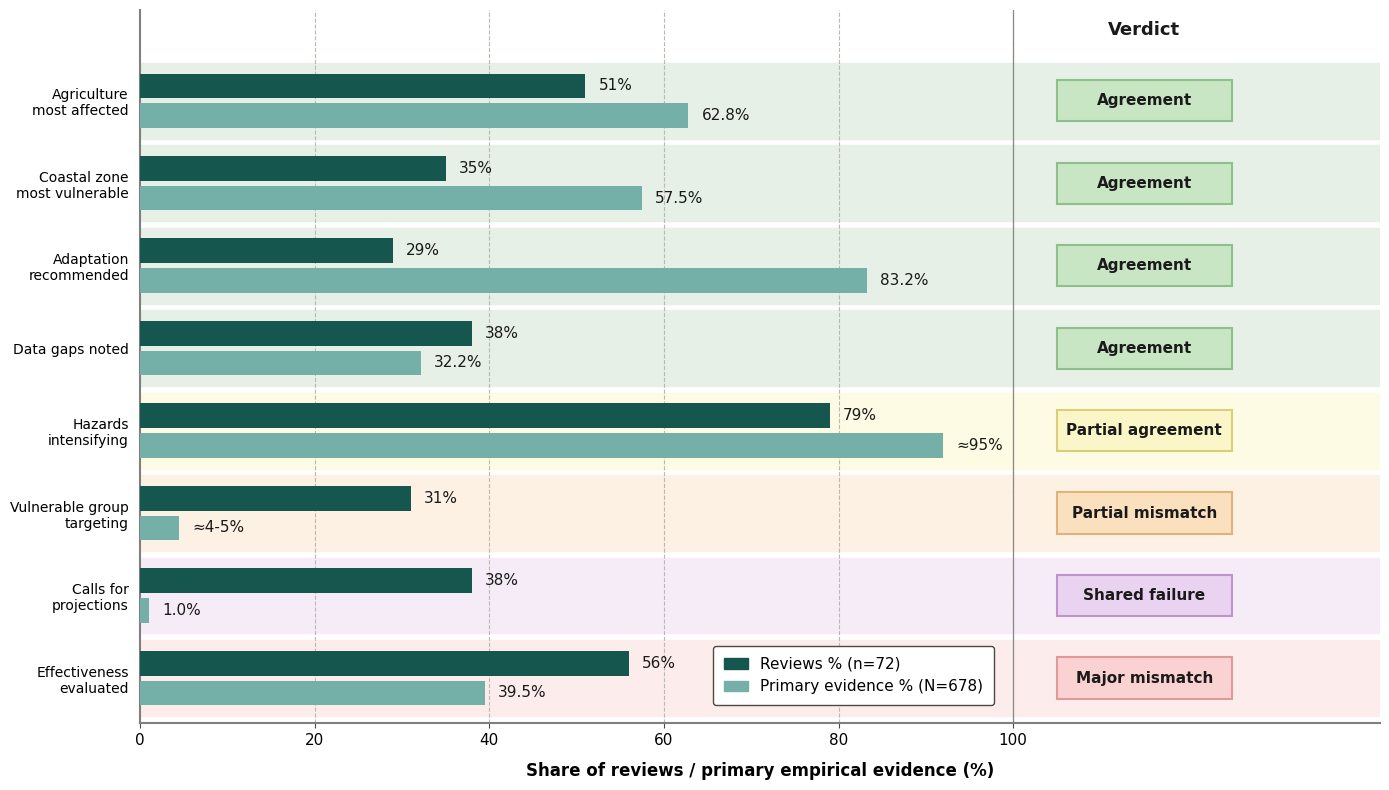

In [50]:
import textwrap
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches # Import for creating custom shapes

# ----------------------------------------------------------------------
# Data (top row first)
# label, reviews %, primary bar length, reviews text, primary text, verdict key
ROWS = [
    ("Hazards\nintensifying",                79, 92.0, "79%", "\u224895%",     "partial_agreement"),
    ("Agriculture\nmost affected",           51, 62.8, "51%", "62.8%",         "agreement"),
    ("Coastal zone\nmost vulnerable",        35, 57.5, "35%", "57.5%",         "agreement"),
    ("Adaptation\nrecommended",              29, 83.2, "29%", "83.2%",         "agreement"),
    ("Effectiveness\nevaluated",             56, 39.5, "56%", "39.5%",         "major_mismatch"),
    ("Calls for\nprojections",               38,  1.0, "38%", "1.0%",          "shared_failure"),
    ("Vulnerable group\ntargeting", 31, 4.5, "31%", "\u22484-5%",   "partial_mismatch"),
    ("Data gaps noted",                     38, 32.2, "38%", "32.2%",         "agreement"),
]

VERDICTS = {
    "agreement":         ("Agreement",         "#e6f0e6", "#c8e6c4", "#8fbf8a"),
    "partial_agreement": ("Partial agreement", "#fdfbe4", "#fbf6c8", "#d9cf7a"),
    "major_mismatch":    ("Major mismatch",    "#fdecec", "#fbd2d2", "#e09a9a"),
    "shared_failure":    ("Shared failure",    "#f5ecf8", "#e9d3f0", "#bf93cc"),
    "partial_mismatch":  ("Partial mismatch",  "#fdf1e3", "#fbe0bd", "#dfb27e"),
}
# (verdict text, band fill, box fill, box edge)

DARK_TEAL = "#15564f"   # Reviews bars
LIGHT_TEAL = "#74b0a8"  # Primary evidence bars

X_MAX = 100          # data axis ends here
X_RIGHT = 142        # bands and verdict boxes extend into this region
VERDICT_X = 115      # centre of the verdict boxes
WRAP_WIDTH = 26      # characters per line for y labels

# Define fixed dimensions for verdict boxes (in data coordinates)
# These values are chosen to fit 'Partial agreement' well while being uniform.
VERDICT_BOX_WIDTH = 20
VERDICT_BOX_HEIGHT = 0.5

# Define the desired order of verdicts
VERDICT_ORDER = [
    "agreement",
    "partial_agreement",
    "partial_mismatch",
    "shared_failure",
    "major_mismatch",
]

# Sort ROWS based on the defined VERDICT_ORDER
ROWS.sort(key=lambda x: VERDICT_ORDER.index(x[5]))

# ----------------------------------------------------------------------
# Figure: base size was 14 x 7 in; height raised by 1 inch to widen bars
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#ffffff")

n = len(ROWS)
row_h = 1.0
bar_h = 0.30
offset = 0.18  # distance of each bar centre from the row centre

y_centres = [n - 1 - i for i in range(n)]  # first row on top

for (label, rev, prim, rev_txt, prim_txt, key), yc in zip(ROWS, y_centres):
    _, band, _, _ = VERDICTS[key]

    # background band for the whole row, spanning to the right edge
    ax.axhspan(yc - row_h / 2 + 0.04, yc + row_h / 2 - 0.04,
               xmin=0, xmax=1, color=band, zorder=0)

    # bars: reviews on top, primary evidence below
    ax.barh(yc + offset, rev,  height=bar_h, color=DARK_TEAL,  zorder=3)
    ax.barh(yc - offset, prim, height=bar_h, color=LIGHT_TEAL, zorder=3)

    # value labels just past the bar ends
    ax.text(rev + 1.5,  yc + offset, rev_txt,  va="center", ha="left",
            fontsize=11, color="#1a1a1a", zorder=4)
    ax.text(prim + 1.5, yc - offset, prim_txt, va="center", ha="left",
            fontsize=11, color="#1a1a1a", zorder=4)

    # verdict box on the right (now drawn as a fixed-size rectangle)
    verdict, _, box_fill, box_edge = VERDICTS[key]

    # Calculate bottom-left corner for the fixed-size rectangle
    rect_x = VERDICT_X - (VERDICT_BOX_WIDTH / 2)
    rect_y = yc - (VERDICT_BOX_HEIGHT / 2)

    # Create and add the rectangle patch
    rect = mpatches.Rectangle((rect_x, rect_y), VERDICT_BOX_WIDTH, VERDICT_BOX_HEIGHT,
                              facecolor=box_fill, edgecolor=box_edge,
                              linewidth=1.5, zorder=4)
    ax.add_patch(rect)

    # Place the text centered within the new rectangle (without its own bbox)
    ax.text(VERDICT_X, yc, verdict, va="center", ha="center",
            fontsize=11, fontweight="bold", color="#1a1a1a", zorder=5)

# "Verdict" column header
ax.text(VERDICT_X, n - 0.25, "Verdict", ha="center", va="bottom",
        fontsize=13, fontweight="bold", color="#1a1a1a")

# ----------------------------------------------------------------------
# Axes cosmetics
ax.set_xlim(0, X_RIGHT)
ax.set_ylim(-0.55, n - 0.45 + 0.55)

ax.set_xticks(np.arange(0, X_MAX + 1, 20))
ax.set_xticklabels([str(t) for t in range(0, X_MAX + 1, 20)], fontsize=11)
ax.set_xlabel("Share of reviews / primary empirical evidence (%)",
              fontsize=12, fontweight="bold", labelpad=10)

# wrap long category names onto two lines, preserving explicit newlines
ax.set_yticks(y_centres)

new_labels = []
for r in ROWS:
    parts = r[0].split('\n')
    wrapped_parts = []
    for part in parts:
        wrapped_parts.extend(textwrap.wrap(part, WRAP_WIDTH))
    new_labels.append('\n'.join(wrapped_parts))
labels = new_labels

ax.set_yticklabels(labels,
                   fontsize=10)
# Explicitly set multialignment for y-tick labels and increase padding
for label in ax.get_yticklabels():
    label.set_multialignment('right')
ax.tick_params(axis="y", length=0, pad=8)

# dashed vertical gridlines, only over the data region
for x in np.arange(20, X_MAX + 1, 20):
    ax.axvline(x, color="#b9b9b4", linestyle="--", linewidth=0.8, zorder=1)
ax.axvline(X_MAX, color="#8a8a85", linestyle="-", linewidth=0.9, zorder=1)

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#7f7f7f")  # Changed to gray
ax.spines["left"].set_linewidth(1.5) # Added linewidth
ax.spines["bottom"].set_color("#7f7f7f") # Changed to gray
ax.spines["bottom"].set_linewidth(1.5) # Added linewidth
ax.tick_params(axis="x", color="#4a4a46")

# legend inside the plot, lower right of the data area
handles = [
    plt.Rectangle((0, 0), 1, 1, color=DARK_TEAL,  label="Reviews % (n=72)"),
    plt.Rectangle((0, 0), 1, 1, color=LIGHT_TEAL, label="Primary evidence % (N=678)"),
]
leg = ax.legend(handles=handles, loc="lower right",
                bbox_to_anchor=(0.695, 0.015), fontsize=11,
                frameon=True, framealpha=1.0, edgecolor="#4a4a46",
                borderpad=0.7, handlelength=1.6)
leg.get_frame().set_facecolor("white")

plt.tight_layout()
plt.savefig("Gap verdict.png", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.savefig("Gap verdict.pdf", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())